# Lineare Regression: Einkommen vorhersagen (`ConvertedTotalComp`)



In [1]:
import pandas as pd
import numpy as np


from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

In [3]:

df = pd.read_csv("../One-Hot-Encoded.csv")


q98 = df["ConvertedCompTotal"].dropna().quantile(0.98)
df = df[df["ConvertedCompTotal"] <= q98].copy()
print(df["ConvertedCompTotal"].describe())

bool_cols = df.select_dtypes(include=['bool']).columns

for col in bool_cols:
    df[col] = df[col].astype(int)
df.dtypes

count     21785.000000
mean      86982.492836
std       63772.008524
min           0.000000
25%       40873.000000
50%       75924.190383
75%      120000.000000
max      331000.000000
Name: ConvertedCompTotal, dtype: float64


MaxAge                                                            float64
AgeNum                                                            float64
WorkExp                                                           float64
YearsCode                                                         float64
RemoteCategoryNum                                                 float64
                                                                   ...   
AIAgents_no, i use ai exclusively in copilot/autocomplete mode      int64
AIAgents_yes, i use ai agents at work daily                         int64
AIAgents_yes, i use ai agents at work monthly or infrequently       int64
AIAgents_yes, i use ai agents at work weekly                        int64
AIAgents_nan                                                        int64
Length: 484, dtype: object

In [ ]:
TARGET = "ConvertedCompTotal"

num_cols = df.select_dtypes(include=["number"]).columns.tolist()
feature_cols = [c for c in num_cols if c != TARGET]

X = df[feature_cols].copy()
y = df[TARGET].copy()
X = X.drop(columns=["ConvertedCompYearly"])


# Konsistentes Dropna (X vollständig + y vorhanden)
mask = X.notna().all(axis=1) & y.notna()
X = X.loc[mask].copy()
y = y.loc[mask].copy()

print("After dropna -> X:", X.shape, "y:", y.shape)
y.describe()

After dropna -> X: (15428, 467) y: (15428,)


count     15428.000000
mean      91800.239447
std       62085.501875
min           0.000000
25%       47969.373211
50%       81746.000000
75%      125000.000000
max      331000.000000
Name: ConvertedCompTotal, dtype: float64

In [6]:
y_model = y.astype(float)
y_model.head()

0     61659.84
1    105102.00
3     36435.36
7     72000.00
8     70000.00
Name: ConvertedCompTotal, dtype: float64

In [7]:
# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_model,
    test_size=0.2,
    random_state=42
)

print("Train:", X_train.shape, "Test:", X_test.shape)

Train: (12342, 467) Test: (3086, 467)


In [8]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler

num_cols = ["MaxAge", "AgeNum", "WorkExp", "YearsCode", "RemoteCategoryNum"]
dummy_cols = [c for c in X.columns if c not in num_cols]

preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("dum", "passthrough", dummy_cols),
    ],
    remainder="drop"
)


In [ ]:

scaler = StandardScaler()
X_train_sc = preprocess.fit_transform(X_train)
X_test_sc  = preprocess.transform(X_test)



In [10]:
clf = LinearRegression()
clf.fit(X_train_sc, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [13]:
predicted = clf.predict(X_test_sc)
expected = y_test

print ("RMSE:")
rmse = np.sqrt(mean_squared_error(expected, predicted))
print (rmse)
print("R^2:")
r2 = r2_score(expected, predicted)
print (r2)
print("MAE:")
mae = mean_absolute_error(expected, predicted)
print (mae)

RMSE:
39409.44777923649
R^2:
0.5870960776910581
MAE:
27384.226552834054


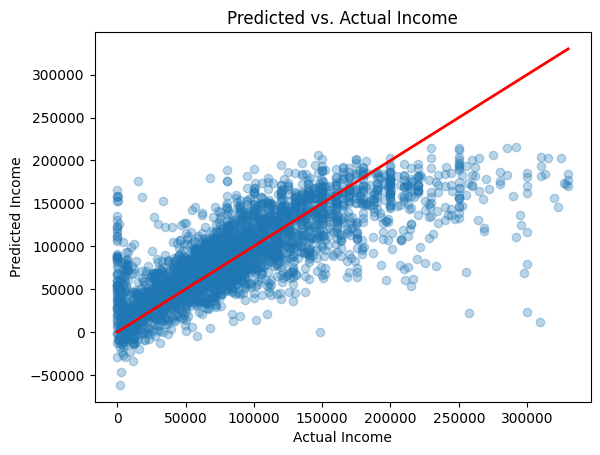

In [14]:
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(expected, predicted, alpha=0.3)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red", linewidth=2
)
plt.xlabel("Actual Income")
plt.ylabel("Predicted Income")
plt.title("Predicted vs. Actual Income")
plt.show()



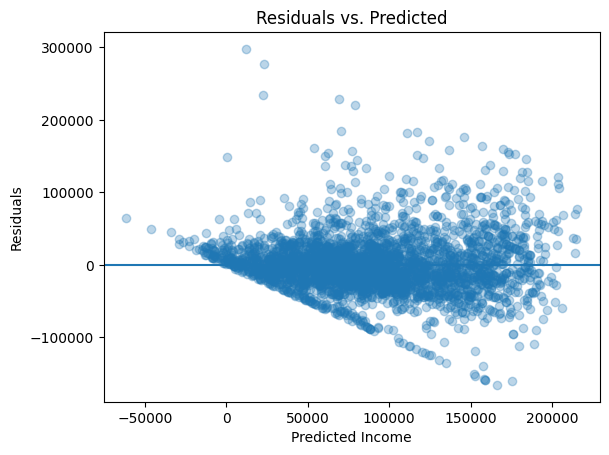

In [15]:
residuals = expected - predicted

plt.figure()
plt.scatter(predicted, residuals, alpha=0.3)
plt.axhline(0)
plt.xlabel("Predicted Income")
plt.ylabel("Residuals")
plt.title("Residuals vs. Predicted")
plt.show()


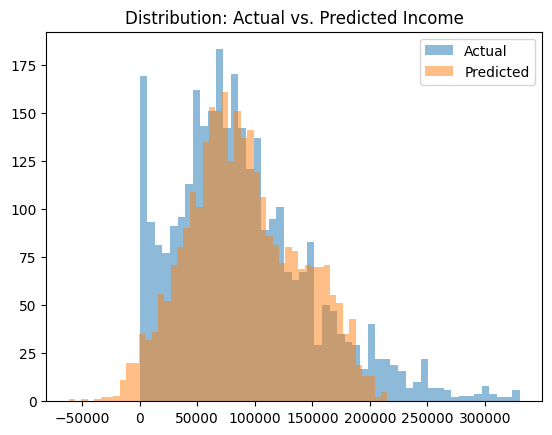

In [16]:
plt.figure()
plt.hist(expected, bins=50, alpha=0.5, label="Actual")
plt.hist(predicted, bins=50, alpha=0.5, label="Predicted")
plt.legend()
plt.title("Distribution: Actual vs. Predicted Income")
plt.show()
